In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["NPOC"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".5"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "true"
os.environ["NPROC"] = "1"
os.environ["intra_op_parallelism_threads"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import bilby as bb
import gwpopulation as gwpop
import jax
import matplotlib.pyplot as plt
import pandas as pd
from bilby.core.prior import PriorDict, Uniform, TruncatedNormal
from bilby.hyper.model import Model
from gwpopulation.experimental.jax import JittedLikelihood

gwpop.set_backend("jax")

xp = gwpop.utils.xp

%matplotlib inline

/home/noah.wolfe/.conda/envs/just-for-kicks/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
datadir = '../../data/stegmann'
posteriors = pd.read_pickle(f"{datadir}/gwtc4_posteriors.pkl")
injections = pd.read_pickle(f"{datadir}/gwtc4_injections_dict.pkl")

In [3]:
# We are considering the default Gaussian_Isotropic_Cut spin model from Stegmann et al. (2025)
label = 'Gaussian_Isotropic_Cut'

################## IMPORTANT SETTINGS ##################

# Control maximum uncertainty in selection function estimation
# For production runs (as used in Stegmann et al. (2025)), I recommend setting maximum_uncertainty = 1, naccept = 5, nlive = 1000 (which should take several hours)
# For quick tests, you can set maximum_uncertainty = xp.inf, naccept = 5, nlive = 100 (which should take several minutes)
maximum_uncertainty = xp.inf
naccept = 5
nlive = 100

########################################################

# Define custom spin model
def spin_model(dataset, mu_1, sigma_1, mu_tilt_1, sigma_tilt_1, 
               mu_2, sigma_2, mu_3, sigma_3,
               weight_a, m_cut):
    
    # Unpack variables from dataset
    a_1 = dataset["a_1"]
    a_2 = dataset["a_2"]
    cos_tilt_1 = dataset["cos_tilt_1"]
    cos_tilt_2 = dataset["cos_tilt_2"]
    m_1 = dataset["mass_1"]

    # Free Gaussian component
    comp1 = gwpop.utils.truncnorm(a_1, mu_1, sigma_1, 1, 0) * \
            gwpop.utils.truncnorm(a_2, mu_1, sigma_1, 1, 0) * \
            gwpop.utils.truncnorm(cos_tilt_1, mu_tilt_1, sigma_tilt_1, 1, -1) * \
            gwpop.utils.truncnorm(cos_tilt_2, mu_tilt_1, sigma_tilt_1, 1, -1)

    # Isotropic component
    comp2 = gwpop.utils.truncnorm(a_1, mu_2, sigma_2, 1, 0) * \
            gwpop.utils.truncnorm(a_2, mu_2, sigma_2, 1, 0) * \
            0.5 * 0.5 
    
    # High-mass isotropic component
    comp3 = gwpop.utils.truncnorm(a_1, mu_3, sigma_3, 1, 0) * \
            gwpop.utils.truncnorm(a_2, mu_3, sigma_3, 1, 0) * \
            0.5 * 0.5 
    
    # Mass-dependent transition function
    zeta = 1/(1 + xp.exp(-m_1+m_cut))
    
    # Combine components with mass-dependent transition
    return (1 - zeta) * (weight_a * comp1 + (1 - weight_a) * comp2) + zeta * comp3

# Define the full population model, combining mass, spin, and redshift models
model = Model(
    model_functions=[
        gwpop.models.mass.two_component_primary_mass_ratio,
        spin_model,
        gwpop.models.redshift.PowerLawRedshift(cosmo_model="Planck15"),
    ],
    cache=False,
)

vt = gwpop.vt.ResamplingVT(model=model, data=injections, n_events=len(posteriors))

# for resampling individual event posteriors
np.random.seed(42)

likelihood = gwpop.hyperpe.HyperparameterLikelihood(
    posteriors=posteriors,
    hyper_prior=model,
    selection_function=vt,
    maximum_uncertainty=maximum_uncertainty,
)

# Define priors for hyperparameters
priors = PriorDict()

# mass
priors["alpha"] = Uniform(minimum=-2, maximum=4, latex_label="$\\alpha$")
priors["beta"] = Uniform(minimum=-4, maximum=12, latex_label="$\\beta$")
priors["mmin"] = Uniform(minimum=2, maximum=2.5, latex_label="$m_{\\min}$")
priors["mmax"] = Uniform(minimum=80, maximum=100, latex_label="$m_{\\max}$")
priors["lam"] = Uniform(minimum=0, maximum=1, latex_label="$\\lambda_{m}$")
priors["mpp"] = Uniform(minimum=10, maximum=50, latex_label="$\\mu_{m}$")
priors["sigpp"] = Uniform(minimum=1, maximum=10, latex_label="$\\sigma_{m}$")
priors["gaussian_mass_maximum"] = 100
# spin
priors["mu_1"] = Uniform(minimum=0, maximum=1, latex_label="$\\mu_1$")
priors["sigma_1"] = Uniform(minimum=0.1, maximum=1, latex_label="$\\sigma_1$")
priors["mu_tilt_1"] = Uniform(minimum=-1, maximum=1, latex_label="$\\mu_{t,1}$")
priors["sigma_tilt_1"] = TruncatedNormal(minimum=0.1, maximum=4, sigma=1/2, mu=0, latex_label="$\\sigma_{t,1}$")
priors["mu_2"] = Uniform(minimum=0, maximum=1, latex_label="$\\mu_2$")
priors["sigma_2"] = Uniform(minimum=0.1, maximum=1, latex_label="$\\sigma_2$")
priors["weight_a"] = Uniform(minimum=0, maximum=1, latex_label="$w_a$")
priors["mu_3"] = Uniform(minimum=0, maximum=1, latex_label="$\\mu_3$")
priors["sigma_3"] = Uniform(minimum=0.1, maximum=1, latex_label="$\\sigma_3$")
priors["m_cut"] = Uniform(minimum=10, maximum=100, latex_label="$m_{\\rm cut}$")

# redshift
priors["lamb"] = Uniform(minimum=-1, maximum=10, latex_label="$\\lambda_{z}$")

# Test JittedLikelihood
parameters = priors.sample()
likelihood.parameters.update(parameters)
likelihood.log_likelihood_ratio()
print(likelihood.log_likelihood_ratio())
jit_likelihood = JittedLikelihood(likelihood)
jit_likelihood.parameters.update(parameters)
print(jit_likelihood.log_likelihood_ratio())
print(jit_likelihood.log_likelihood_ratio())

# Run sampler
result = bb.run_sampler(
    likelihood=jit_likelihood,
    priors=priors,
    sampler="dynesty",
    nlive=nlive,
    label=label,
    sample="acceptance-walk",
    naccept=naccept,
    save="hdf5",
    outdir="out_" + label,
    sampling_seed=746566
)

NameError: name 'np' is not defined

In [1]:
from bilby.core.result import read_in_result

res = read_in_result(
    '/home/noah.wolfe/projects/tilts-and-kicks/data/inference/strong/multimass/stegmann/default-spin-simple-power-law-mass-var-1/run_result.hdf5'
)

In [2]:
import h5ify
posterior = h5ify.load(
    '/home/noah.wolfe/projects/tilts-and-kicks/data/inference/strong/multimass/stegmann/default-spin-simple-power-law-mass-var-1/posterior.h5'
)

In [3]:
posterior['samples']['variance'] = posterior['variance']

In [7]:
posterior['samples'].pop('gaussian_mass_maximum')

array([100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
       100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 10

In [8]:
posterior['samples'].pop('log_likelihood');
posterior['samples'].pop('log_prior');

In [9]:
posterior['samples'].keys()

dict_keys(['alpha', 'beta', 'lam', 'lamb', 'm_cut', 'mmax', 'mmin', 'mpp', 'mu_1', 'mu_2', 'mu_3', 'mu_tilt_1', 'sigma_1', 'sigma_2', 'sigma_3', 'sigma_tilt_1', 'sigpp', 'weight_a', 'variance'])

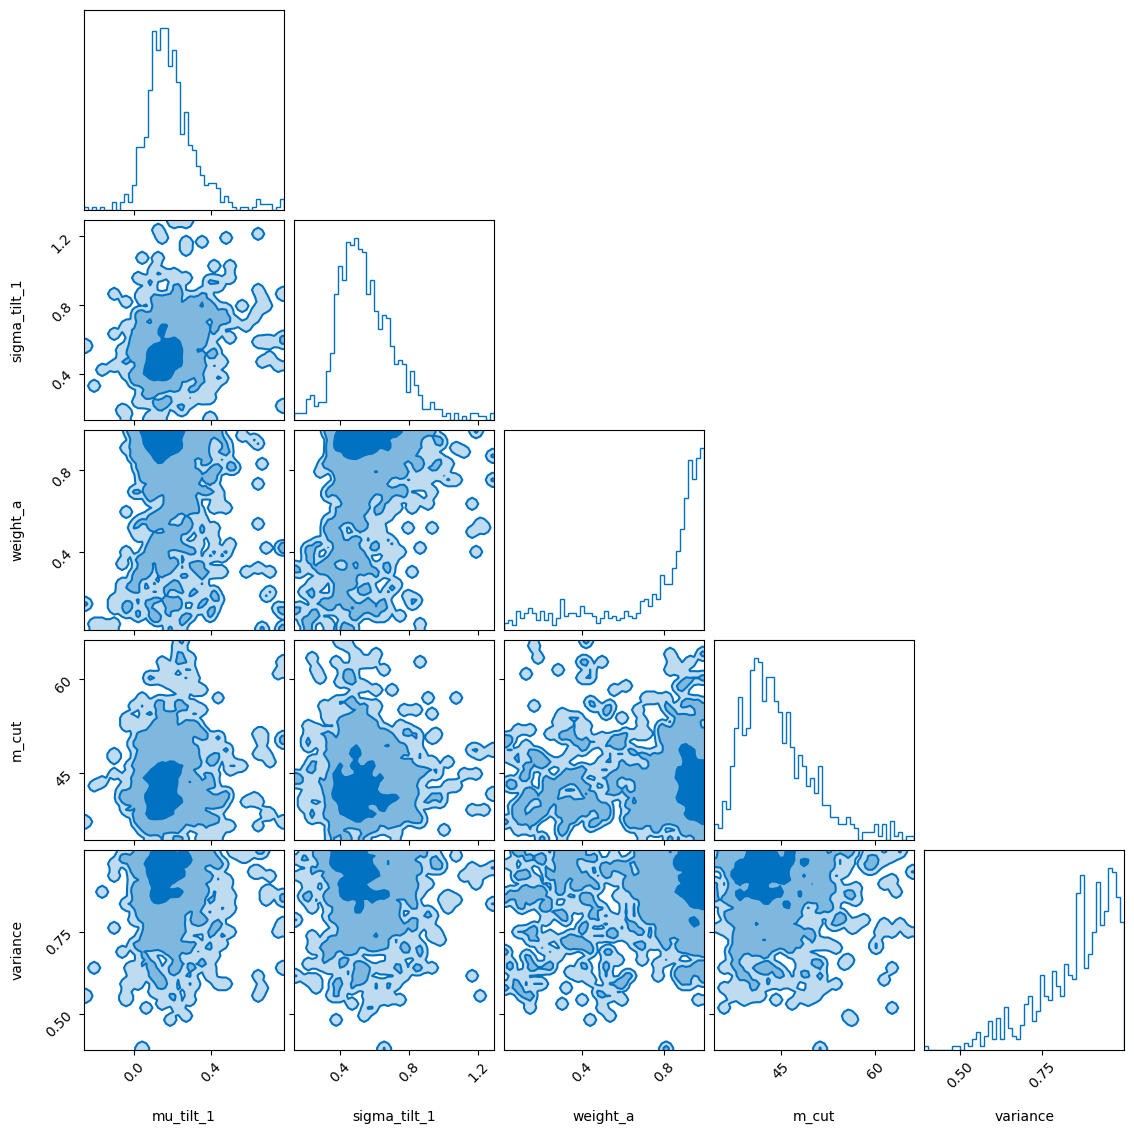

In [5]:
from util import plot_corner
import numpy as np

keys = ['mu_tilt_1', 'sigma_tilt_1', 'weight_a', 'm_cut', 'variance']

fig = plot_corner(
    np.column_stack([
        posterior['samples'][k] for k in keys
    ]),
    labels=keys,
    fname='/home/noah.wolfe/projects/tilts-and-kicks/data/inference/strong/multimass/stegmann/default-spin-simple-power-law-mass-var-1/like-fig4.png'
)

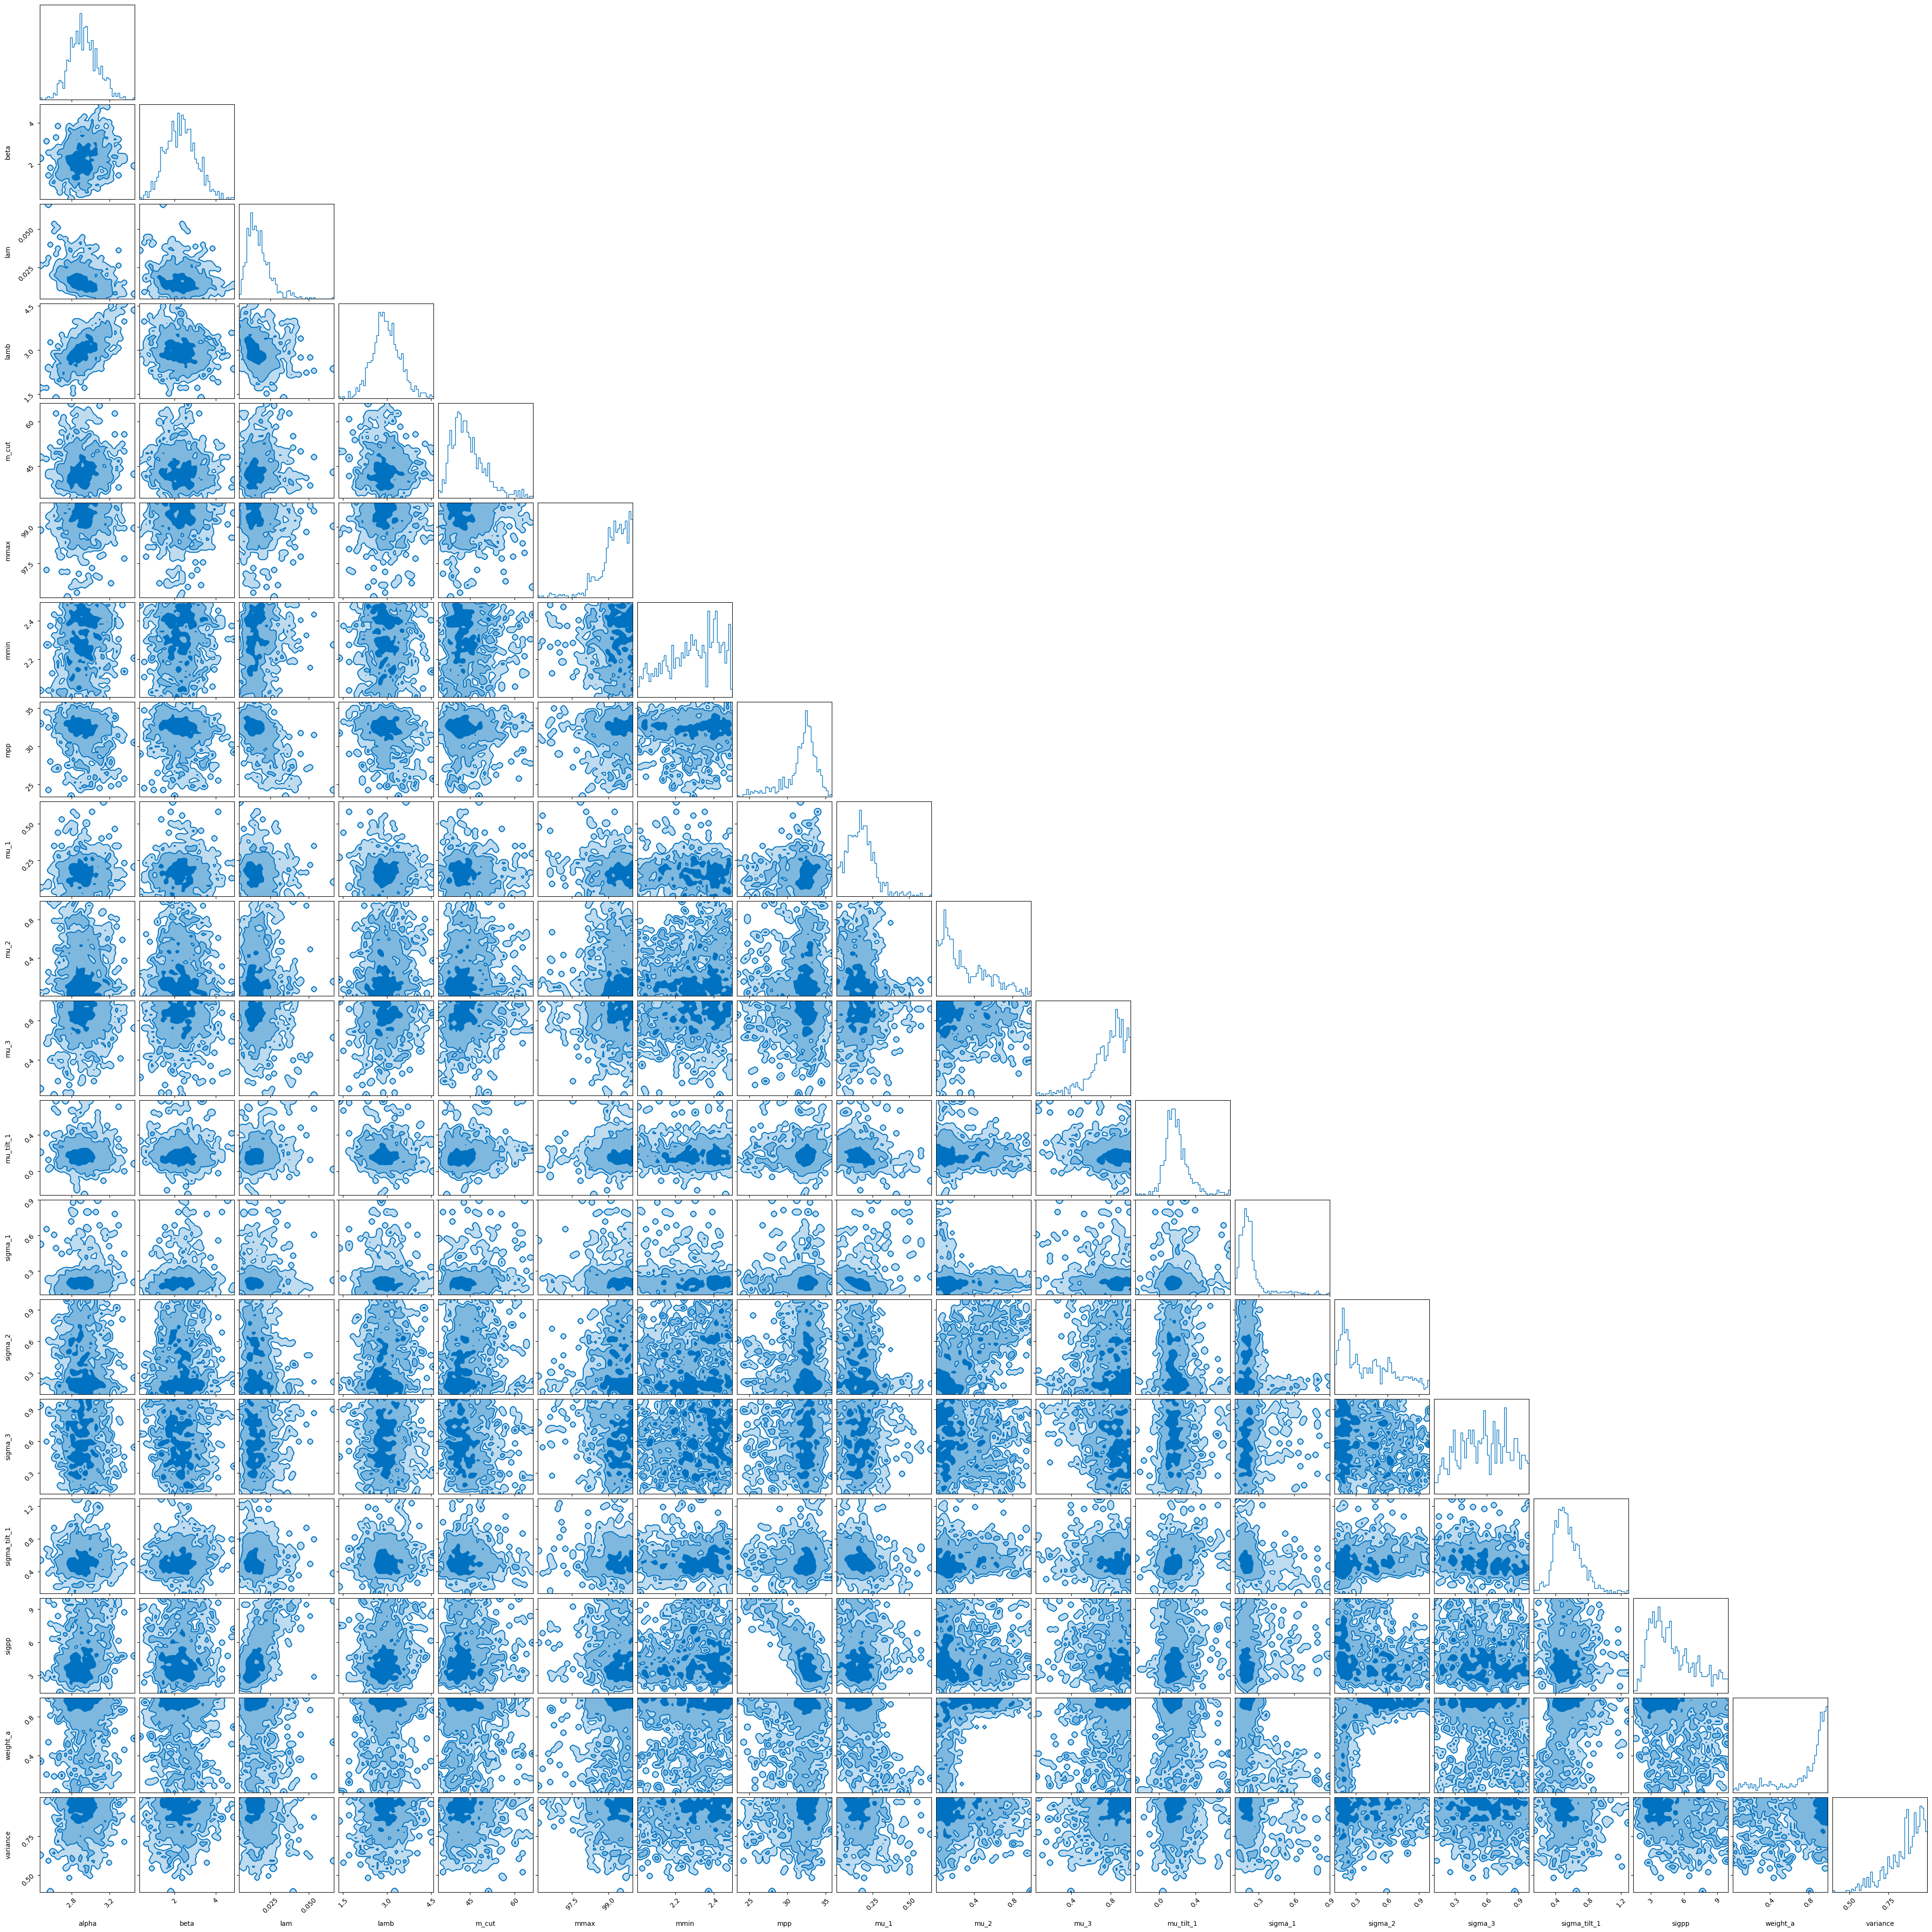

In [11]:
from util import plot_corner
import numpy as np

keys = list(posterior['samples'].keys())

fig = plot_corner(
    np.column_stack([
        posterior['samples'][k] for k in keys
    ]),
    labels=keys,
    fname='/home/noah.wolfe/projects/tilts-and-kicks/data/inference/strong/multimass/stegmann/default-spin-simple-power-law-mass-var-1/run_corner.png'
)

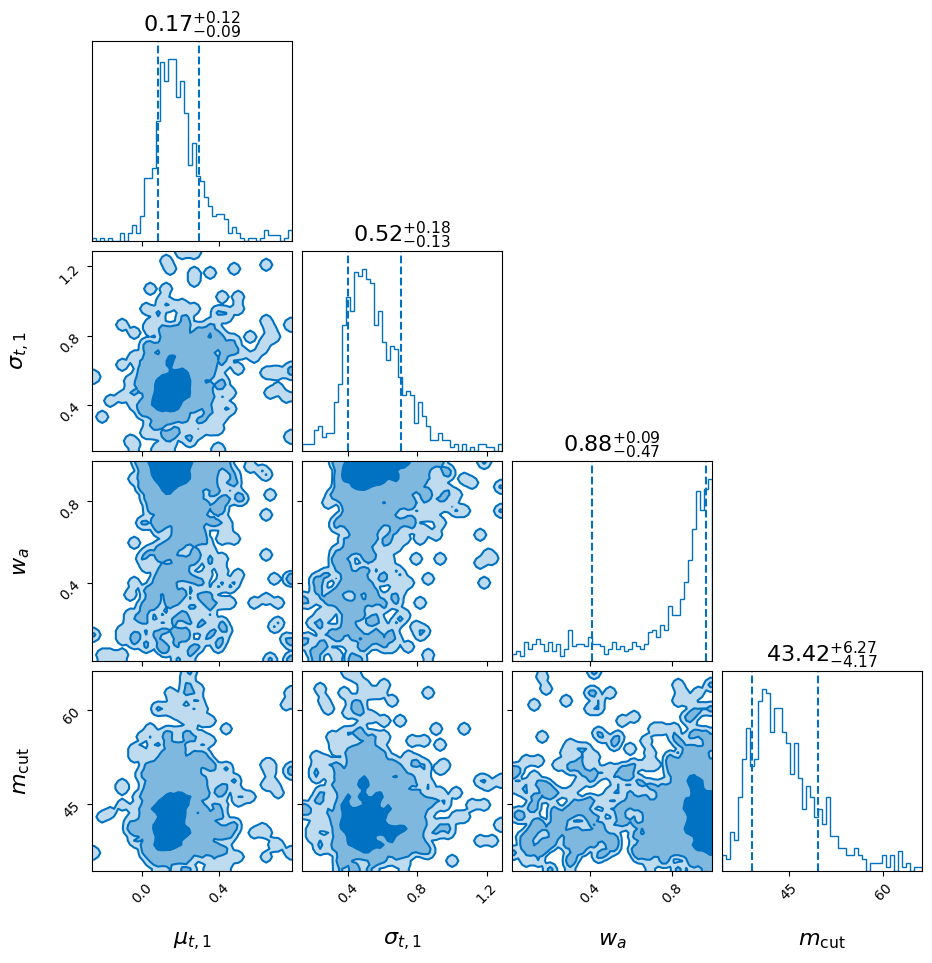

In [9]:
res.plot_corner(
    filename='/home/noah.wolfe/projects/tilts-and-kicks/data/inference/strong/multimass/stegmann/default-spin-simple-power-law-mass-var-1/like-fig4.png',
    parameters=['mu_tilt_1', 'sigma_tilt_1', 'weight_a', 'm_cut']
)

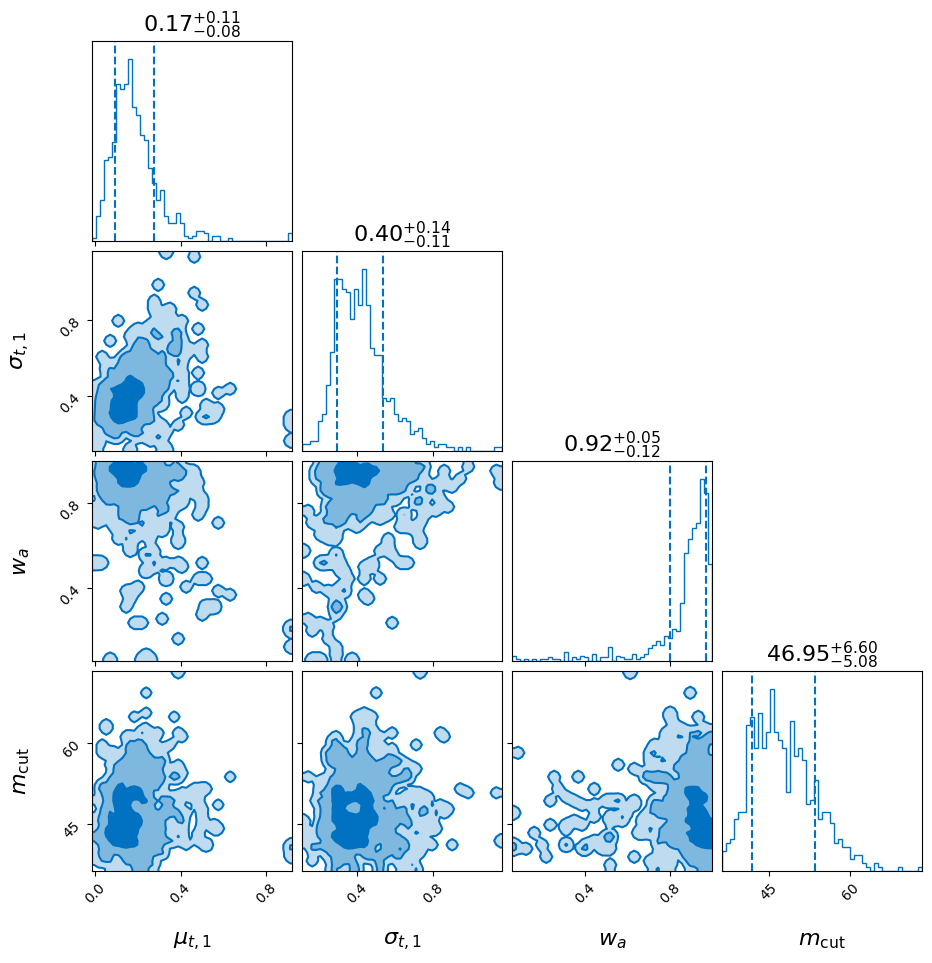

In [7]:
result.plot_corner(parameters=['mu_tilt_1', 'sigma_tilt_1', 'weight_a', 'm_cut'])